
--- Starting ConvNeXt-Base Training on Skin2025 ---
Epoch [02/10] | Train Acc: 97.89% | Val Acc: 97.07%
Epoch [03/10] | Train Acc: 98.85% | Val Acc: 98.03%
Epoch [07/10] | Train Acc: 99.94% | Val Acc: 98.70%
Epoch [08/10] | Train Acc: 99.98% | Val Acc: 98.77%
Epoch [09/10] | Train Acc: 99.99% | Val Acc: 98.80%
Epoch [10/10] | Train Acc: 100.00% | Val Acc: 98.80%

--- Evaluating Best Model on Held-out Blind Test Split ---

>>> CONVNEXT-BASE SKIN2025 FINAL METRICS:
    Accuracy            : 98.77%
    Macro F1            : 0.9877
    ROC-AUC             : 0.9985
    Malignant Recall    : 99.13%
    Benign Specificity  : 98.40%

              precision    recall  f1-score   support

      Benign     0.9913    0.9840    0.9876      1500
   Malignant     0.9841    0.9913    0.9877      1500

    accuracy                         0.9877      3000
   macro avg     0.9877    0.9877    0.9877      3000
weighted avg     0.9877    0.9877    0.9877      3000



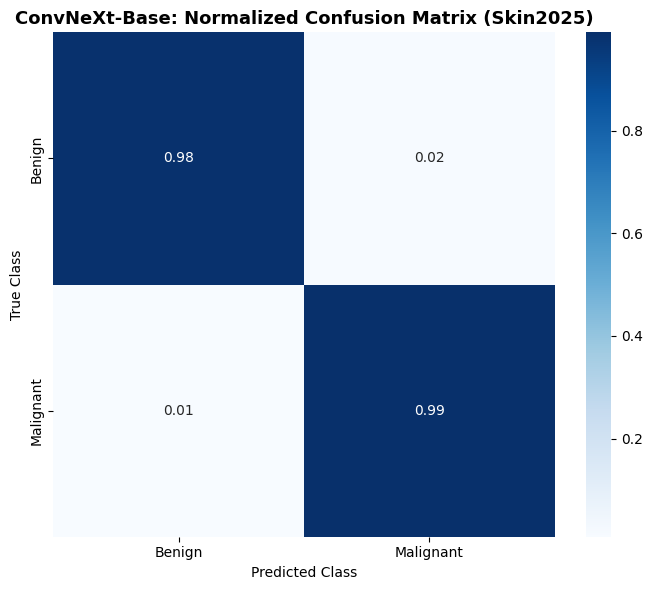

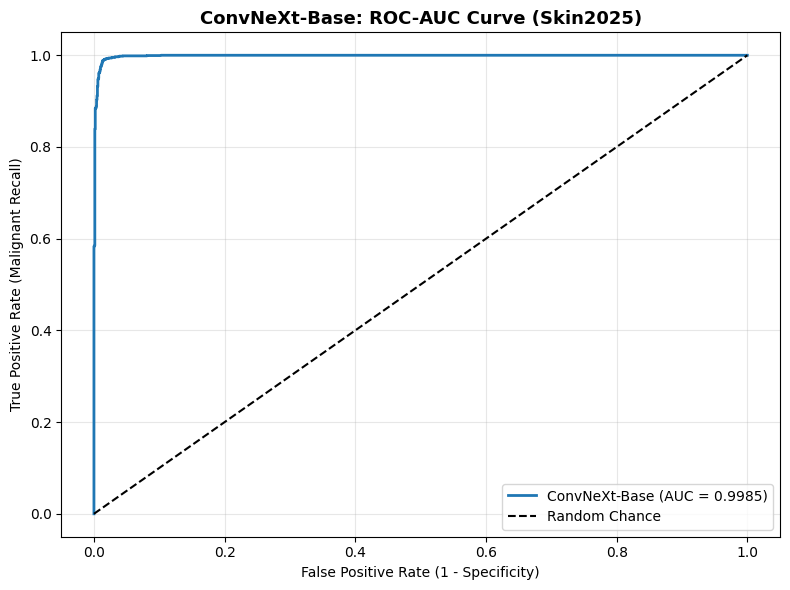

[+] Bundle ready for direct download to Google Drive / Local PC:


/kaggle/working/convnext_skin2025_results.zip

In [1]:
# ==============================================================================
# BENCHMARK: ConvNeXt-Base on Skin2025 (Binary: Benign vs Malignant)
# Course: CSE463 Computer Vision Term Project
# Output: best_convnext_base_skin2025.pth, metrics CSV, and diagnostic plots
# ==============================================================================

import os
import glob
import copy
import zipfile
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.amp import autocast, GradScaler
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
)
from IPython.display import FileLink

# 1. Environment & Paths Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = "/kaggle/working/convnext_skin2025_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_NAME = "ConvNeXt-Base"
TIMM_TAG = "convnext_base.fb_in22k_ft_in1k"
NUM_CLASSES = 2
BATCH_SIZE = 32
NUM_WORKERS = 4
EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 1e-2
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"[+] Active GPU: {DEVICE} | Model: {MODEL_NAME}")

# 2. Skin2025 Path Discovery & Stratified Split
def load_skin2025_splits(base_dir="/kaggle/input"):
    all_imgs = glob.glob(os.path.join(base_dir, "**", "*.[jJ][pP][gG]"), recursive=True) + \
               glob.glob(os.path.join(base_dir, "**", "*.[pP][nN][gG]"), recursive=True) + \
               glob.glob(os.path.join(base_dir, "**", "*.[jJ][pP][eE][gG]"), recursive=True)
    
    records = []
    for path in all_imgs:
        path_lower = path.lower()
        if "benign" in path_lower:
            records.append({'path': path, 'label': 0, 'class_name': 'benign'})
        elif "malignant" in path_lower or "melanoma" in path_lower:
            records.append({'path': path, 'label': 1, 'class_name': 'malignant'})
            
    df = pd.DataFrame(records).drop_duplicates(subset=['path']).reset_index(drop=True)
    print(f"[+] Discovered {len(df)} images across classes: {df['class_name'].value_counts().to_dict()}")
    
    # 70/15/15 Stratified Split (Yields ~3,000 blind test images for 20,000 total)
    train_val, test_df = train_test_split(df, test_size=0.15, stratify=df['label'], random_state=SEED)
    train_df, val_df = train_test_split(train_val, test_size=0.1765, stratify=train_val['label'], random_state=SEED)
    
    print(f"[+] Splits -> Train: {len(train_df)} | Val: {len(val_df)} | Blind Test: {len(test_df)}")
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

# 3. Dataset & Transforms
class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label']
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

train_df, val_df, test_df = load_skin2025_splits()
train_loader = DataLoader(SkinDataset(train_df, train_transforms), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(SkinDataset(val_df, eval_transforms), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(SkinDataset(test_df, eval_transforms), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# 4. Training Engine
model = timm.create_model(TIMM_TAG, pretrained=True, num_classes=NUM_CLASSES).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()
scaler = GradScaler('cuda')

best_val_acc = 0.0
weight_path = os.path.join(OUTPUT_DIR, "best_convnext_base_skin2025.pth")

print("\n--- Starting ConvNeXt-Base Training on Skin2025 ---")
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, train_correct, total_train = 0.0, 0, 0
    for images, targets in train_loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        with autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * targets.size(0)
        train_correct += (outputs.argmax(1) == targets).sum().item()
        total_train += targets.size(0)
        
    scheduler.step()
    
    # Validation Pass
    model.eval()
    val_correct, total_val = 0, 0
    with torch.no_grad():
        for images, targets in val_loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            with autocast('cuda'):
                outputs = model(images)
            val_correct += (outputs.argmax(1) == targets).sum().item()
            total_val += targets.size(0)
            
    val_acc = val_correct / total_val
    print(f"Epoch [{epoch:02d}/{EPOCHS}] | Train Acc: {(train_correct/total_train)*100:.2f}% | Val Acc: {val_acc*100:.2f}%")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), weight_path)

# 5. Blind Test Evaluation
print("\n--- Evaluating Best Model on Held-out Blind Test Split ---")
model.load_state_dict(torch.load(weight_path))
model.eval()

y_true, y_pred, y_probs = [], [], []
with torch.no_grad():
    for images, targets in test_loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        with autocast('cuda'):
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
        y_true.extend(targets.cpu().numpy())
        y_pred.extend(outputs.argmax(1).cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)
target_names = ['Benign', 'Malignant']

acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
macro_prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
macro_rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
binary_auc = roc_auc_score(y_true, y_probs[:, 1])

# Specificity & Sensitivity
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
benign_specificity = tn / (tn + fp)
malignant_recall = tp / (tp + fn)

print(f"\n>>> CONVNEXT-BASE SKIN2025 FINAL METRICS:")
print(f"    Accuracy            : {acc*100:.2f}%")
print(f"    Macro F1            : {macro_f1:.4f}")
print(f"    ROC-AUC             : {binary_auc:.4f}")
print(f"    Malignant Recall    : {malignant_recall*100:.2f}%")
print(f"    Benign Specificity  : {benign_specificity*100:.2f}%")
print("\n" + classification_report(y_true, y_pred, target_names=target_names, digits=4))

# 6. Generate & Save Confusion Matrix & ROC Curve
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(7, 6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("ConvNeXt-Base: Normalized Confusion Matrix (Skin2025)", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, "convnext_skin2025_confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_probs[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1f77b4', lw=2, label=f"ConvNeXt-Base (AUC = {binary_auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label="Random Chance")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Malignant Recall)")
plt.title("ConvNeXt-Base: ROC-AUC Curve (Skin2025)", fontsize=13, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
roc_path = os.path.join(OUTPUT_DIR, "convnext_skin2025_roc_auc.png")
plt.savefig(roc_path, dpi=300)
plt.show()

# 7. Save Metrics Table & Export ZIP Bundle
metrics_df = pd.DataFrame([{
    "Model": "ConvNeXt-Base",
    "Dataset": "Skin2025",
    "Test Accuracy": f"{acc*100:.2f}%",
    "Macro F1": round(macro_f1, 4),
    "ROC-AUC": round(binary_auc, 4),
    "Malignant Recall": f"{malignant_recall*100:.2f}%",
    "Benign Specificity": f"{benign_specificity*100:.2f}%"
}])
metrics_csv = os.path.join(OUTPUT_DIR, "convnext_skin2025_metrics.csv")
metrics_df.to_csv(metrics_csv, index=False)

zip_file = "/kaggle/working/convnext_skin2025_results.zip"
with zipfile.ZipFile(zip_file, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for f in os.listdir(OUTPUT_DIR):
        zipf.write(os.path.join(OUTPUT_DIR, f), arcname=f)

print("[+] Bundle ready for direct download to Google Drive / Local PC:")
FileLink(r'convnext_skin2025_results.zip')